In [76]:
import pandas as pd

df = pd.read_csv("results.csv")
df

,index,raw_value,sorted_value,exact,mse,bitwidth
0,1,11183780,11169628,11184812,28497141.12,23
1,2,11181988,11169676,11184812,28497141.12,23
2,3,11187052,11174828,11184812,28497141.12,23
3,4,11181556,11175724,11184812,28497141.12,23
4,5,11191212,11175724,11184812,28497141.12,23
...,...,...,...,...,...,...
95,96,11185404,11193724,11184812,28497141.12,23
96,97,11187004,11194204,11184812,28497141.12,23
97,98,11195300,11195300,11184812,28497141.12,23
98,99,11175724,11195628,11184812,28497141.12,23


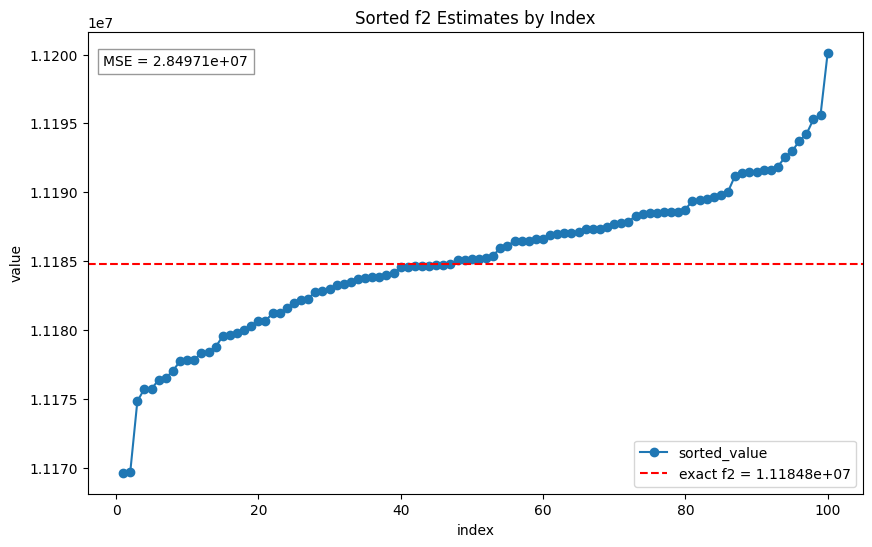

In [77]:
import matplotlib.pyplot as plt

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df['sorted_value'], marker='o', linestyle='-', label='sorted_value')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Sorted f2 Estimates by Index')
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
sorted_f2_ylim = plt.gca().get_ylim()
plt.show()

Vi beregner gennemsnittet for vores estimater og sammenligner med den eksakte F2-værdi,

In [78]:
mean_estimate = df["raw_value"].mean().item()

print(f"Mean of raw_value: {mean_estimate:.6g}")
print(f"Exact f2 value: {exact_f2_value:.6g}")

percentage_error = abs(mean_estimate - exact_f2_value) / exact_f2_value * 100
print(f"Error (|mean - exact|): {abs(mean_estimate - exact_f2_value):.6g} ({percentage_error:.6f}%)")

Mean of raw_value: 1.11851e+07
Exact f2 value: 1.11848e+07
Error (|mean - exact|): 278.48 (0.002490%)


In [79]:
l = df['bitwidth'].iloc[0]
num_buckets = 1 << l
exp_variance = 2*exact_f2_value**2 / num_buckets
print(f"Expected variance of the estimator: {exp_variance:.6g}")
print(f"Empirical variance of the estimator: {mse_value:.6g}")
print(f"Error (|empirical variance - expected variance|): {abs(mse_value - exp_variance):.6g} ({abs(mse_value - exp_variance) / exp_variance * 100:.6f}%)")

Expected variance of the estimator: 2.98262e+07
Empirical variance of the estimator: 2.84971e+07
Error (|empirical variance - expected variance|): 1.32903e+06 (4.455912%)


## Gruppering

In [84]:
# Split raw_value into groups of 11 elements
group_size = 11
num_groups = 9
raw_values = df['raw_value'].values
groups = {f'G_{i+1}': raw_values[i*group_size:(i+1)*group_size] for i in range(num_groups)}
groups

{'G_1': array([11183780, 11181988, 11187052, 11181556, 11191212, 11184748,
        11180668, 11178428, 11184108, 11191636, 11187740]),
 'G_2': array([11187124, 11175724, 11184620, 11191868, 11194204, 11183260,
        11186572, 11185092, 11184572, 11186972, 11189508]),
 'G_3': array([11184548, 11182804, 11178756, 11184724, 11183364, 11177740,
        11183980, 11191388, 11188580, 11185116, 11183676]),
 'G_4': array([11185100, 11181196, 11183812, 11191452, 11179964, 11187348,
        11192964, 11191596, 11176516, 11177828, 11187332]),
 'G_5': array([11174828, 11188284, 11185236, 11182164, 11184612, 11188444,
        11182276, 11169628, 11187852, 11186636, 11189684]),
 'G_6': array([11191468, 11188516, 11181196, 11185156, 11188596, 11187444,
        11185956, 11179756, 11187708, 11184612, 11177828]),
 'G_7': array([11186436, 11192540, 11189788, 11179556, 11186444, 11186124,
        11169676, 11188740, 11182772, 11186468, 11183812]),
 'G_8': array([11195628, 11188580, 11200132, 11187356, 

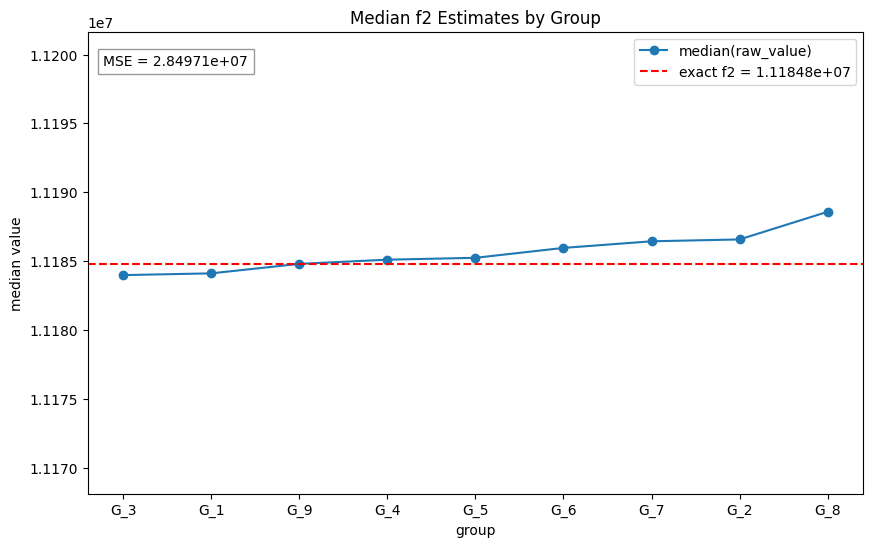

In [85]:
group_size = globals().get('group_size', 11)
raw_values = df['raw_value'].values
num_groups = len(raw_values) // group_size
kvps = {f"G_{i+1}": pd.Series(raw_values[i*group_size:(i+1)*group_size]).median() for i in range(num_groups)}
kvps = {k:v for k,v in sorted(kvps.items(), key=lambda item: item[1])}
group_labels = list(kvps.keys())
medians = list(kvps.values())

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(group_labels, medians, marker='o', linestyle='-', label='median(raw_value)')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Median f2 Estimates by Group')
plt.ylim(globals().get('sorted_f2_ylim', plt.gca().get_ylim()))
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('group')
plt.ylabel('median value')
plt.legend()
plt.show()


Vi kan se at variansen af disse medianværdier,

In [86]:
import numpy as np
np.array(medians).var(ddof=0)

np.float64(1835052.2469135802)

er markant lavere end variansen for alle estimater,

In [87]:
mse_value

np.float64(28497141.12)